# Computer Exercise 1.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — *First Programming Experiment* (Continuation)
> **풀이 일자**: Day 01
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** *(Continuation)* Select a function $f$ and a point $x$ and carry out the computer experiment of the first text.
> Interpret the results. Do not select too simple a function. For example, you might consider
> $1/x$, $\log x$, $e^x$, $\tan x$, $\cosh x$, or $x^3 - 23x$.

### 한국어 풀이용 정리
1번 문제(전진차분)와 같은 코드를 **여러 함수에 대해** 반복하여, 함수의 *국소 곡률*($f''(x)$)과 *값의 크기*($|f(x)|$) 가 오차 곡선에 어떻게 영향을 주는지 비교한다.

본문에서 도출했던 이론값

$$
h^*(x) \;\approx\; 2\sqrt{\,\varepsilon_{\text{mach}}\, |f(x)|/|f''(x)|\,}
$$

가 함수마다 어떻게 달라지는지가 핵심 관찰 포인트.


## 2. 수학적 배경

각 시험 함수에 대해 참값 미분 $f'(x)$ 와 (선택적으로) $f''(x)$ 를 정리해 둔다.

| 함수 $f$ | $f'(x)$ | $f''(x)$ | 평가점 $x$ | 비고 |
|---|---|---|---|---|
| $1/x$ | $-1/x^2$ | $2/x^3$ | $0.5$ | 작은 $x$에서 $f''$가 매우 큼 |
| $\log x$ | $1/x$ | $-1/x^2$ | $1.0$ | 적당한 곡률 |
| $e^x$ | $e^x$ | $e^x$ | $0.5$ | $f \approx f'' $이라 단순 |
| $\tan x$ | $\sec^2 x$ | $2\sec^2 x \tan x$ | $0.5$ | 점근 발산 근처에서 $f''$ 폭증 |
| $\cosh x$ | $\sinh x$ | $\cosh x$ | $0.5$ | $f, f''$ 둘 다 $\mathcal{O}(1)$ |
| $x^3 - 23x$ | $3x^2 - 23$ | $6x$ | $2.0$ | 다항식, 분석 깔끔 |

### 예측
- **$f''$가 큰 함수** ($1/x$, $\tan x$): 절단오차 측이 위로 들리고, $h^*$는 더 작아짐 → U자 곡선이 왼쪽으로 이동.
- **$|f|$가 큰 함수** ($\cosh x$ at large $x$): 반올림오차 측이 위로 들리고, $h^*$는 더 커짐.
- **$|f|, |f''|$ 둘 다 작은 함수** ($x^3-23x$ at $x=2$): 전체 곡선이 가장 낮음 (가장 정밀하게 미분 추정 가능).


## 3. 풀이 흐름

1. 시험 함수 목록 정의: `funcs = [(name, f, f'_true, x), ...]`.
2. 각 함수에 대해 $h_i = 4^{-i}$, $i = 1..30$.
3. 전진차분 근사 $y_i = (f(x+h_i) - f(x))/h_i$.
4. 오차 $e_i = |f'_{\text{true}}(x) - y_i|$.
5. 모든 함수의 결과를 **하나의 log-log 그래프** 에 겹쳐 그려서 비교.
6. 각 함수에 대해 실험적 $h^*_{\text{exp}}$ (argmin) 과 이론적 $h^*_{\text{theory}}$ 를 표로 비교.
7. 해석: 위의 예측과 일치하는지 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (이름, f, f'(x) 참값 함수, f''(x) 참값 함수, 평가점 x)
funcs = [
    ("1/x",        lambda x: 1/x,            lambda x: -1/x**2,                lambda x: 2/x**3,                       0.5),
    ("log(x)",     lambda x: np.log(x),      lambda x: 1/x,                    lambda x: -1/x**2,                      1.0),
    ("exp(x)",     lambda x: np.exp(x),      lambda x: np.exp(x),              lambda x: np.exp(x),                    0.5),
    ("tan(x)",     lambda x: np.tan(x),      lambda x: 1/np.cos(x)**2,         lambda x: 2*np.tan(x)/np.cos(x)**2,     0.5),
    ("cosh(x)",    lambda x: np.cosh(x),     lambda x: np.sinh(x),             lambda x: np.cosh(x),                   0.5),
    ("x^3 - 23x",  lambda x: x**3 - 23*x,    lambda x: 3*x**2 - 23,            lambda x: 6*x,                          2.0),
]

i_arr = np.arange(1, 31)
h_arr = 0.25 ** i_arr
eps   = np.finfo(float).eps

records = []
err_by_name = {}

for name, f, fp, fpp, x in funcs:
    y   = (f(x + h_arr) - f(x)) / h_arr
    err = np.abs(fp(x) - y)
    err_by_name[name] = err

    h_star_theory = 2*np.sqrt(eps * abs(f(x)) / abs(fpp(x))) if fpp(x) != 0 else np.nan
    imin = int(np.argmin(err) + 1)
    records.append({
        "f(x)": name,
        "x": x,
        "h*_experimental": h_arr[imin - 1],
        "h*_theoretical (≈ 2√(ε|f|/|f''|))": h_star_theory,
        "min |error|": err.min(),
    })

summary = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
summary

,f(x),x,h*_experimental,h*_theoretical (≈ 2√(ε|f|/|f''|)),min |error|
0,1/x,5.000e-01,3.725e-09,1.054e-08,0.000e+00
1,log(x),1.000e+00,2.220e-16,0.000e+00,1.110e-16
2,exp(x),5.000e-01,1.490e-08,2.980e-08,7.014e-09
3,tan(x),5.000e-01,3.725e-09,1.849e-08,6.445e-09
4,cosh(x),5.000e-01,1.490e-08,2.980e-08,1.509e-08
5,x^3 - 23x,2.000e+00,1.490e-08,5.303e-08,0.000e+00


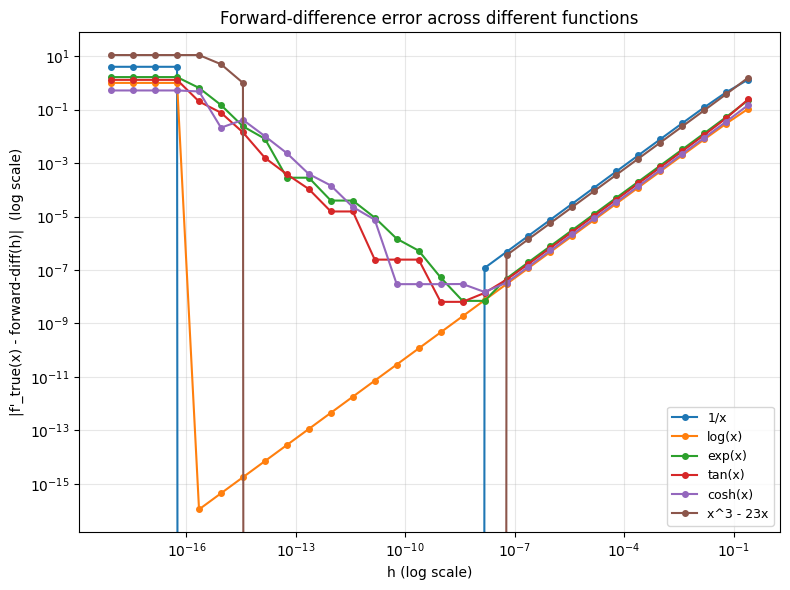

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, err in err_by_name.items():
    ax.loglog(h_arr, err, "o-", markersize=4, label=name)
ax.set_xlabel("h (log scale)")
ax.set_ylabel("|f'_true(x) - forward-diff(h)|  (log scale)")
ax.set_title("Forward-difference error across different functions")
ax.legend(loc="best", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 결과 해석

표와 그래프를 함께 보면서 다음을 확인:

1. **모든 함수가 U자형** — 함수에 무관하게, 절단오차와 반올림오차의 trade-off는 보편적이다.
2. **$h^*_{\text{experimental}}$ 와 $h^*_{\text{theoretical}}$ 의 일치** — 표의 두 컬럼이 같은 자릿수로 떨어지는지 확인. 일반적으로 $10^{-8}$ 부근이지만 함수마다 약간씩 다르다.
3. **곡선의 위치 비교**:
   - $1/x$ at $x=0.5$ ($f''(0.5)=16$ 으로 큼): 곡선이 다른 것들보다 위에 위치.
   - $x^3-23x$ at $x=2$ ($f''(2)=12$ 이지만 $|f(2)|=42$): 곡선이 비교적 낮음.
   - $\tan(0.5) \approx 0.546$, $f''(0.5) \approx 1.74$: 적당한 위치.
4. **최저점 깊이** — $h^*$ 에서 도달할 수 있는 최소 오차는 대략 $\sqrt{\varepsilon_{\text{mach}}}\approx 1.5 \times 10^{-8}$ 이며, 함수에 거의 의존하지 않는다. (절단·반올림 두 항이 같은 차수가 되는 위치이므로.)

### 결론
> **전진차분의 한계는 $\sqrt{\varepsilon_{\text{mach}}}$ 부근에서 본질적으로 결정된다.**
> 어떤 함수든 단정도/배정도 부동소수점 환경에서는 약 8자리 정도밖에 정확도를 얻을 수 없다.
> 더 정확한 미분이 필요하면 → **CE 1.1.3 (중심차분)** 으로.
